In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [31]:
path= 'orders_data_market_basket_analysis.csv'
data= pd.read_csv(path)
df= data.copy()

In [32]:
df.head()

,Order ID,Order Date,Product ID,Category,Product Subcategory,Sales,Quantity,Discount,Profit
0,CA-2017-152156,11/8/2017,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,CA-2017-152156,11/8/2017,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820
2,CA-2017-138688,6/12/2017,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,US-2016-108966,10/11/2016,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310
4,US-2016-108966,10/11/2016,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [33]:
len(df['Order ID'].unique())

5009

In [34]:
c= df.groupby('Order ID')['Product Subcategory'].apply(list)

In [35]:
te= TransactionEncoder()
basket= te.fit_transform(c)
basket= pd.DataFrame(basket, columns= te.columns_)

In [36]:
basket

,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5004,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
5005,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5006,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
5007,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [37]:
fi= apriori(basket, min_support=.01, use_colnames= True)
fi

,support,itemsets
0,0.143342,(Accessories)
1,0.090038,(Appliances)
2,0.145937,(Art)
3,0.262727,(Binders)
4,0.044720,(Bookcases)
...,...,...
63,0.023358,"(Phones, Storage)"
64,0.010381,"(Tables, Phones)"
65,0.010182,"(Paper, Binders, Furnishings)"
66,0.010781,"(Paper, Phones, Binders)"


In [38]:
fi.sort_values('support', ascending= False)
# binders appears in 26% of all transactions
# paper appears in 23% of all transactions

,support,itemsets
3,0.262727,(Binders)
12,0.237772,(Paper)
9,0.175085,(Furnishings)
13,0.162507,(Phones)
14,0.155121,(Storage)
...,...,...
62,0.010781,"(Paper, Tables)"
66,0.010781,"(Paper, Phones, Binders)"
67,0.010581,"(Paper, Storage, Binders)"
64,0.010381,"(Tables, Phones)"


In [39]:
fi['itemsets']= fi['itemsets'].apply(lambda x: x if len(x)== 2 else None)

In [40]:
fi= fi.dropna()

In [41]:
top_pairs= fi.sort_values('support', ascending= False)
# binders > papers frequently bought together 5% of all transactions
# binders, phones 3.9%
top_pairs.head()

,support,itemsets
43,0.054901,"(Paper, Binders)"
44,0.039728,"(Phones, Binders)"
45,0.039728,"(Storage, Binders)"
41,0.039529,"(Binders, Furnishings)"
61,0.035536,"(Paper, Storage)"


In [42]:
top_pairs['item1'] = top_pairs['itemsets'].apply(lambda x: list(x)[0])
top_pairs['item2'] = top_pairs['itemsets'].apply(lambda x: list(x)[1])

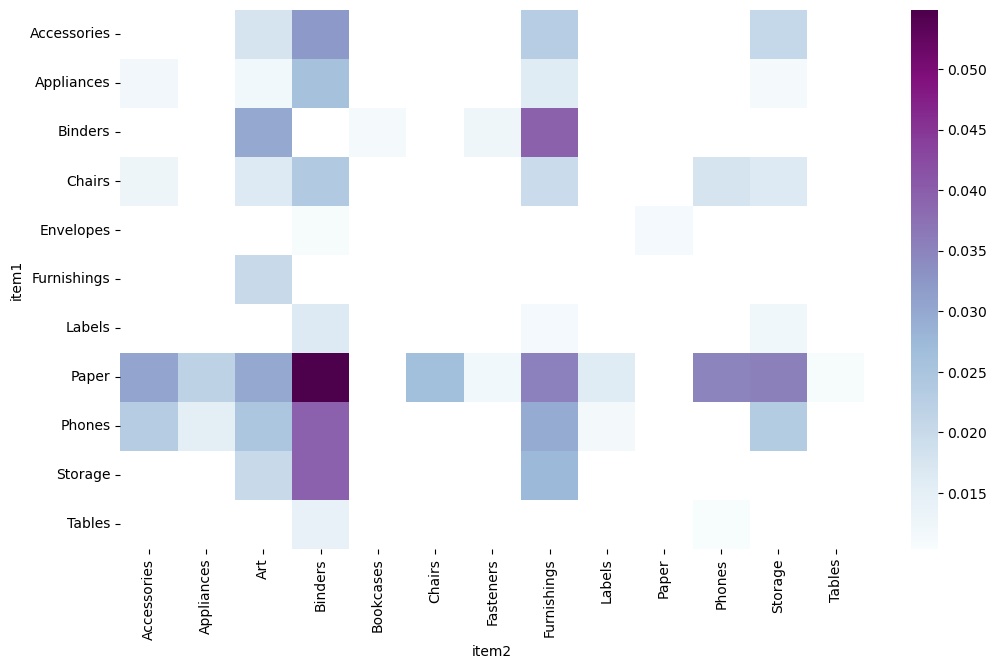

In [43]:
heatmap= pd.crosstab(top_pairs['item1'], top_pairs['item2'], values= top_pairs['support'], aggfunc= 'mean',
                     dropna= True)
plt.figure(figsize= (12 ,7))
sns.heatmap(heatmap, cmap= 'BuPu')
plt.show()

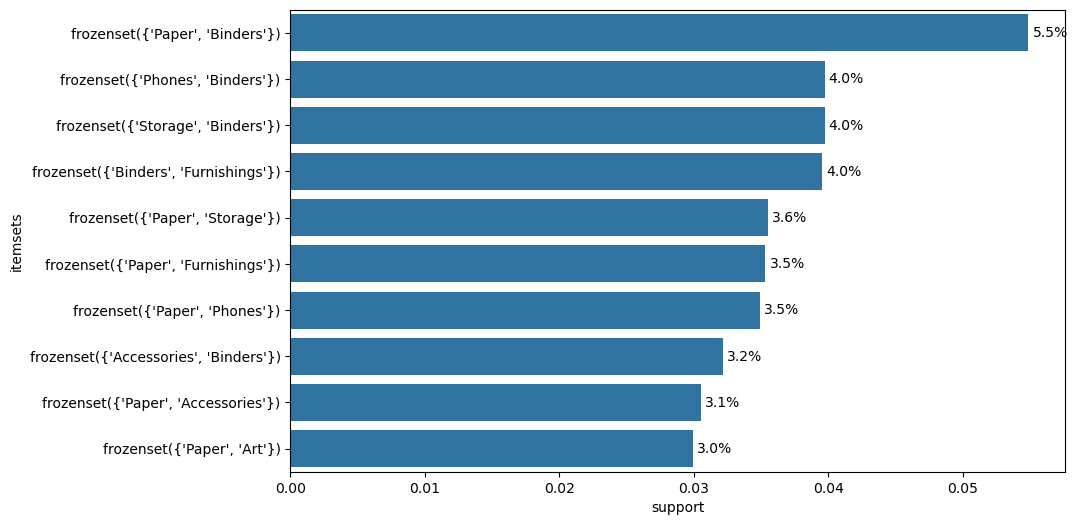

In [44]:
# Sorting and selecting top 10
fi_top10 = fi.sort_values('support', ascending=False).head(10)


plt.figure(figsize=(10, 6))
ax = sns.barplot(data=fi_top10, x='support', y='itemsets')

# Create percentage labels (e.g., 0.054 -> 5.4%)
labels = [f'{val*100:.1f}%' for val in fi_top10['support']]

# Use padding to push text to the right of the bar
ax.bar_label(ax.containers[0], labels=labels, padding=3)
plt.show()

In [45]:
fi3= apriori(basket, min_support=.01, use_colnames= True)
fi3['itemsets']= fi3['itemsets'].apply(lambda x: x if len(x)== 3 else None)
fi3= fi3.dropna()
fi3.head()

,support,itemsets
65,0.010182,"(Paper, Binders, Furnishings)"
66,0.010781,"(Paper, Phones, Binders)"
67,0.010581,"(Paper, Storage, Binders)"


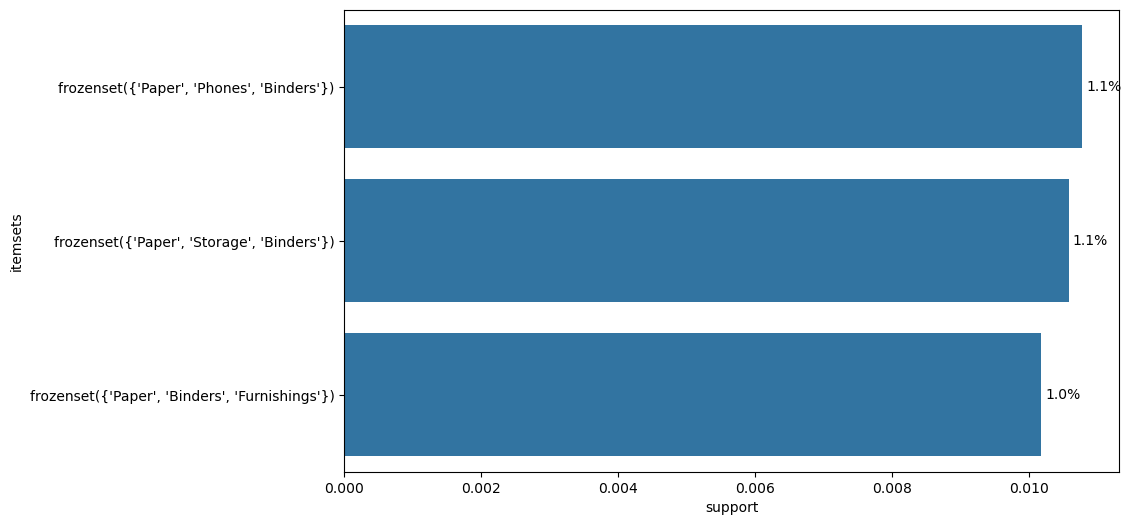

In [46]:
# Sorting and selecting top 10
fi3_top10 = fi3.sort_values('support', ascending=False).head(10)


plt.figure(figsize=(10, 6))
ax = sns.barplot(data=fi3_top10, x='support', y='itemsets')

# Create percentage labels (e.g., 0.054 -> 5.4%)
labels = [f'{val*100:.1f}%' for val in fi3_top10['support']]

# Use padding to push text to the right of the bar
ax.bar_label(ax.containers[0], labels=labels, padding=3)
plt.show()

In [47]:
fi= apriori(basket, min_support=.01, use_colnames= True)

In [48]:
ar= association_rules(fi, metric= 'lift', min_threshold=1)
ar= ar.iloc[:,:7]
ar= ar.sort_values('lift', ascending= False)
ar.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
41,(Storage),"(Paper, Binders)",0.155121,0.054901,0.010581,0.068211,1.242434
36,"(Paper, Binders)",(Storage),0.054901,0.155121,0.010581,0.192727,1.242434
31,"(Paper, Binders)",(Phones),0.054901,0.162507,0.010781,0.196364,1.208336
34,(Phones),"(Paper, Binders)",0.162507,0.054901,0.010781,0.066339,1.208336
35,(Binders),"(Paper, Phones)",0.262727,0.034937,0.010781,0.041033,1.174494


### Time Series Modeling

### EDA

In [49]:
df= df[['Order Date','Product Subcategory','Sales','Discount']]
df.head()

,Order Date,Product Subcategory,Sales,Discount
0,11/8/2017,Bookcases,261.9600,0.00
1,11/8/2017,Chairs,731.9400,0.00
2,6/12/2017,Labels,14.6200,0.00
3,10/11/2016,Tables,957.5775,0.45
4,10/11/2016,Storage,22.3680,0.20


In [53]:
df['Order Date']= pd.to_datetime(df['Order Date'])

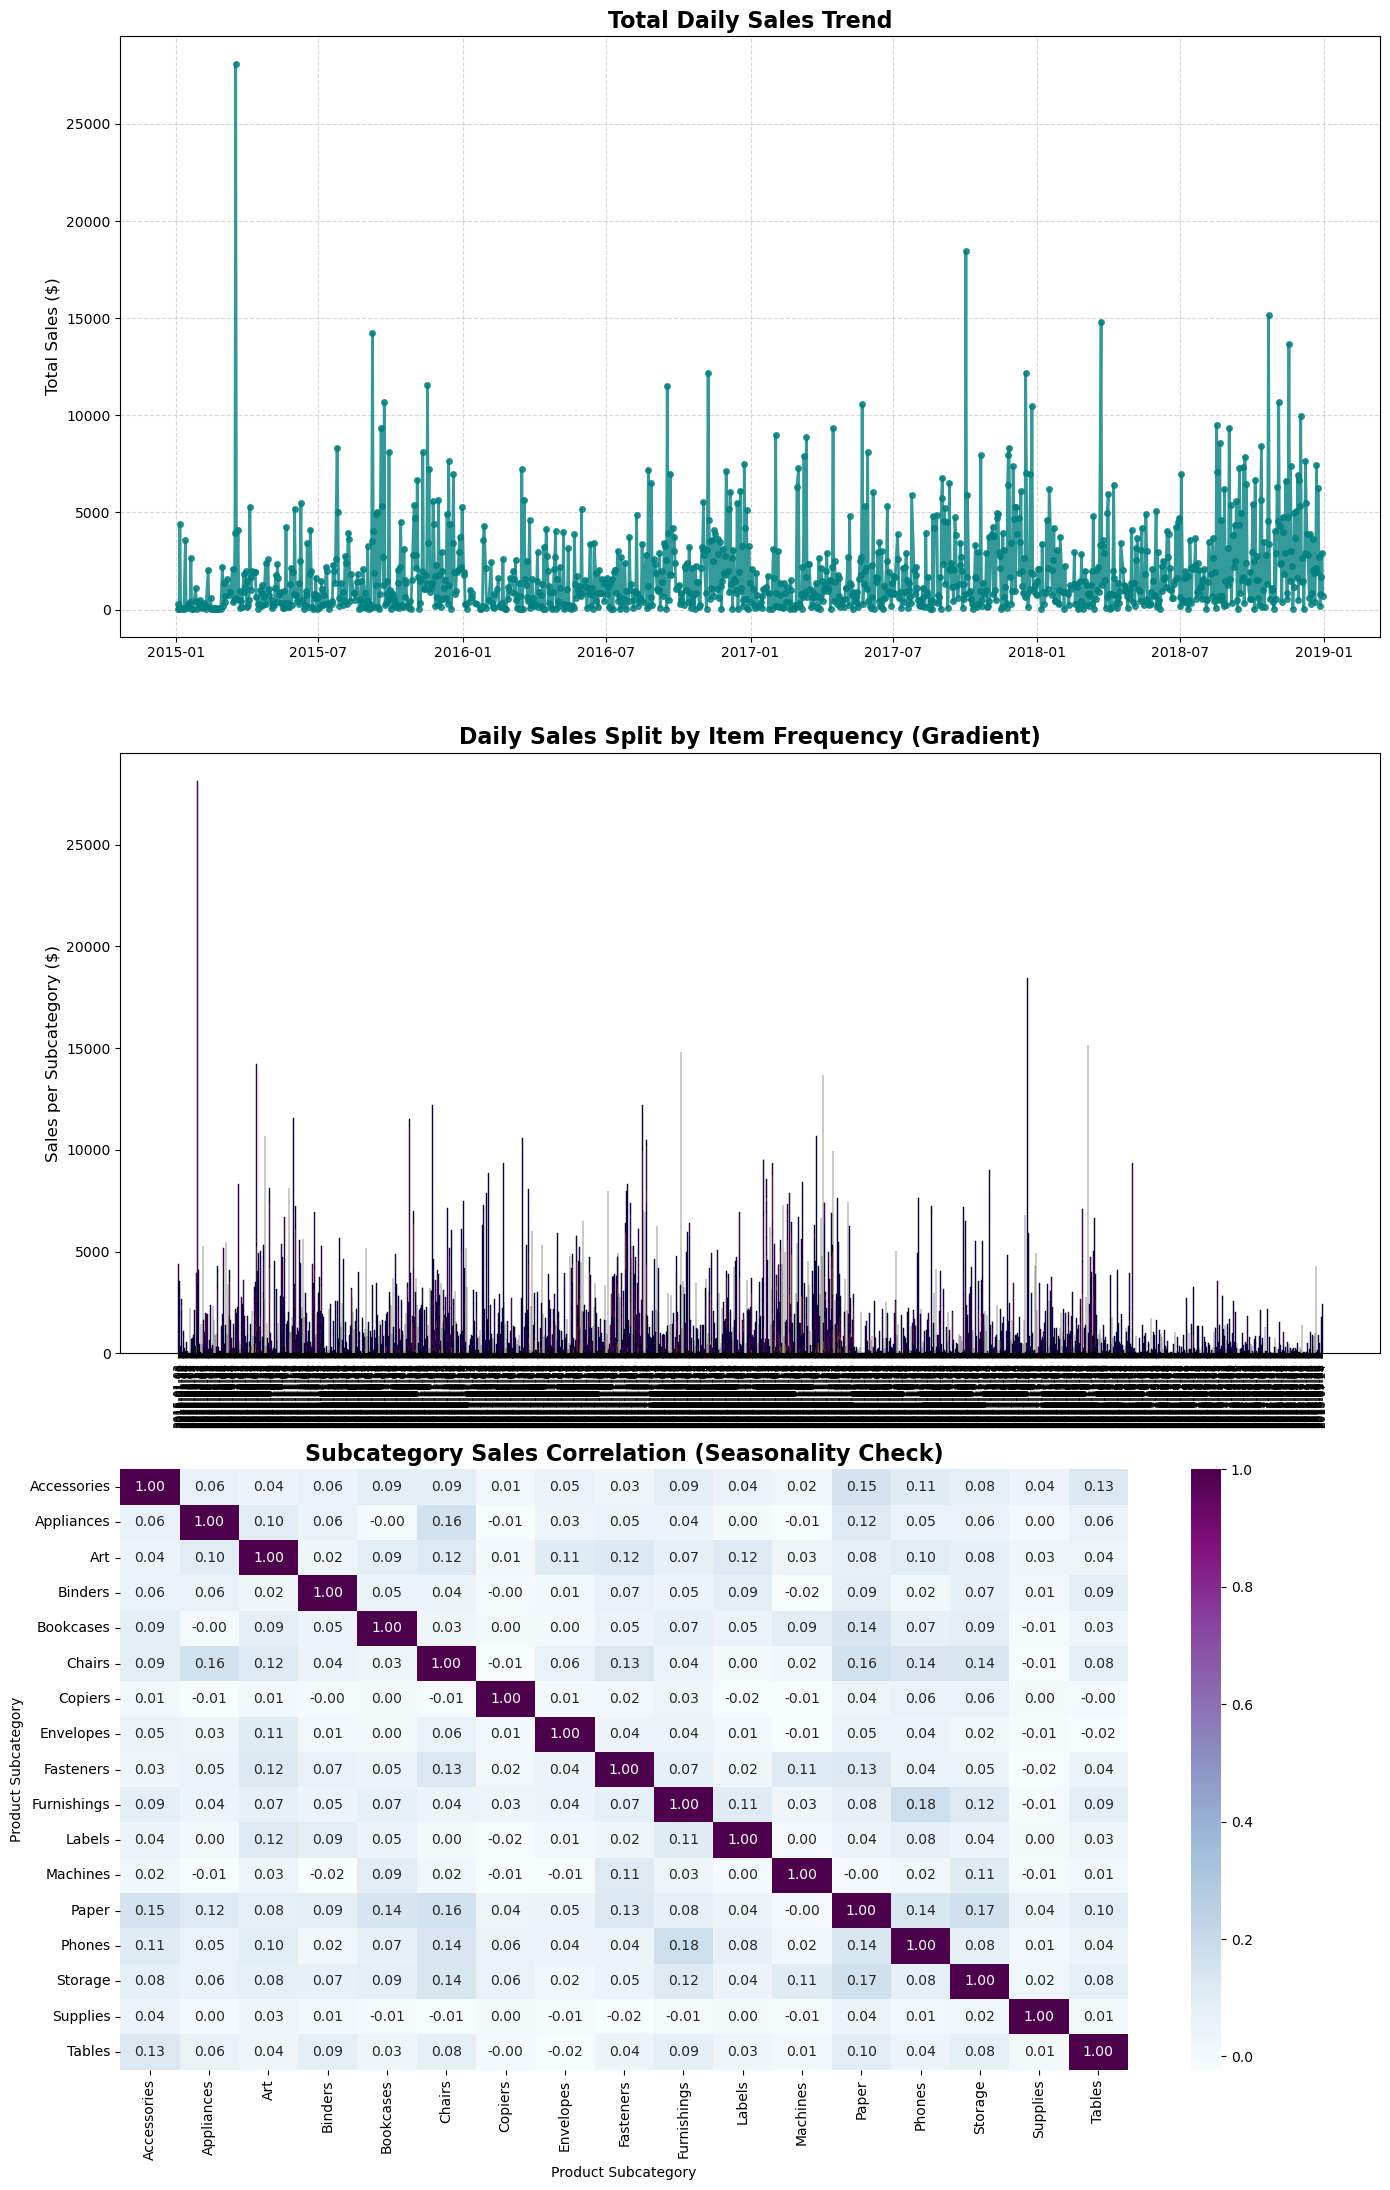

In [54]:
import numpy as np
import matplotlib.colors as mcolors

# Ensure 'Order Date' is datetime and sorted
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')

# 1. Aggregating data
daily_sales = df.groupby('Order Date')['Sales'].sum()

# 2. Aggregating for the frequency-gradient bar plot
daily_item_stats = df.groupby(['Order Date', 'Product Subcategory']).agg(
    sales_sum=('Sales', 'sum'),
    item_freq=('Product Subcategory', 'count') 
).reset_index()

# 3. Pivot for correlation
pivot_df = df.pivot_table(index='Order Date', columns='Product Subcategory', values='Sales', aggfunc='sum').fillna(0)
corr_matrix = pivot_df.corr()

# --- Plotting ---
fig, axes = plt.subplots(3, 1, figsize=(14, 22))

# Subplot 1: Daily Line Plot
axes[0].plot(daily_sales.index, daily_sales.values, color='#008080', linewidth=2, marker='o', markersize=4, alpha=0.8)
axes[0].set_title('Total Daily Sales Trend', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Item Frequency Gradient Bar Chart
unique_dates = sorted(daily_item_stats['Order Date'].unique())
date_strs = [d.strftime('%Y-%m-%d') for d in unique_dates]
subcats = daily_item_stats['Product Subcategory'].unique()

norm = mcolors.Normalize(vmin=daily_item_stats['item_freq'].min(), vmax=daily_item_stats['item_freq'].max())
cmap = plt.cm.plasma
bottoms = np.zeros(len(unique_dates))

for sub in subcats:
    for i, d in enumerate(unique_dates):
        mask = (daily_item_stats['Order Date'] == d) & (daily_item_stats['Product Subcategory'] == sub)
        row = daily_item_stats[mask]
        if not row.empty:
            sales = row['sales_sum'].values[0]
            color = cmap(norm(row['item_freq'].values[0]))
            axes[1].bar(date_strs[i], sales, bottom=bottoms[i], color=color, edgecolor='black', linewidth=0.3)
            bottoms[i] += sales

axes[1].set_title('Daily Sales Split by Item Frequency (Gradient)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Sales per Subcategory ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=90, labelsize=8)

# Subplot 3: Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='BuPu', ax=axes[2])
axes[2].set_title('Subcategory Sales Correlation (Seasonality Check)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

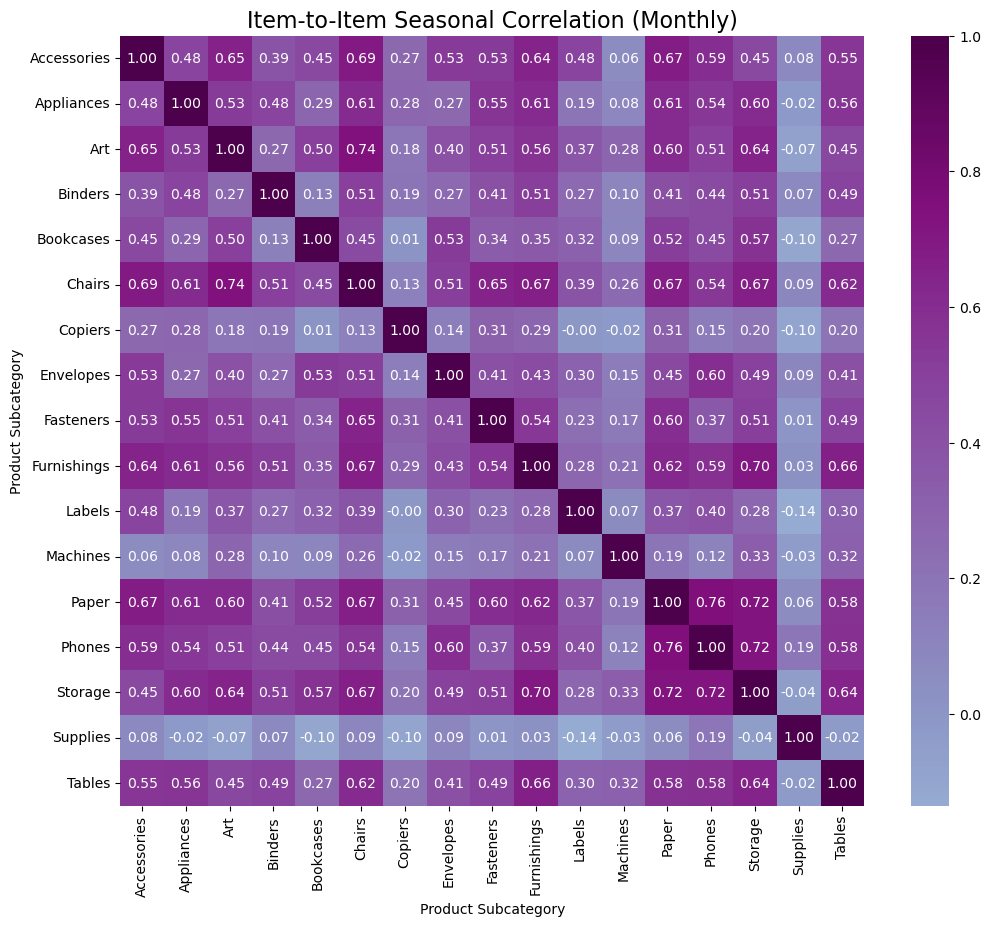

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the Index
# Ensure 'Order Date' is datetime and set as the index
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.set_index('Order Date', inplace=True)

# 2. Pivot: Aggregate Sales by Month ('M')
# Columns = Product Subcategory, Rows = Months
item_monthly_sales = df.pivot_table(index=df.index.to_period('M'), 
                                    columns='Product Subcategory', 
                                    values='Sales', 
                                    aggfunc='sum').fillna(0)

# 3. Compute Seasonal Correlation Matrix
# This calculates Pearson's r at a monthly granularity
item_corr = item_monthly_sales.corr()

# 4. Plotting the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(item_corr, annot=True, fmt=".2f", cmap='BuPu', center=0)
plt.title("Item-to-Item Seasonal Correlation (Monthly)", fontsize=16)
plt.show()

In [59]:
# 1. Get unique dates from your data
unique_dates = df.index.unique()

# 2. Create the full expected range
full_range = pd.date_range(start='2015-01-03', end='2018-12-30')

# 3. Find missing days
missing_days = full_range.difference(unique_dates)

print(f"Total missing days: {len(missing_days)}")
if len(missing_days) > 0:
    print(f"Sample missing days: {missing_days[:5]}")

Total missing days: 222
Sample missing days: DatetimeIndex(['2015-01-08', '2015-01-12', '2015-01-17', '2015-01-22',
               '2015-01-24'],
              dtype='datetime64[ns]', freq=None)


### Preprocessing

In [69]:
# 1. Pivot the data: Rows = Date, Columns = Subcategory, Values = Sales
# This makes the index UNIQUE (one row per day)
df_pivot = df.pivot_table(index='Order Date', 
                          columns='Product Subcategory', 
                          values='Sales', 
                          aggfunc='sum').fillna(0)

# 2. Now Reindex works! (1,458 rows x 17 subcategories)
full_range = pd.date_range(start='2015-01-03', end='2018-12-30')
df_final = df_pivot.reindex(full_range, fill_value=0)

# 3. Optional: Melt it back to "Long" format if you prefer that for XGBoost
df_long = df_final.reset_index().melt(id_vars='index', var_name='Subcategory', value_name='Sales')
df_long.rename(columns={'index': 'Order Date'}, inplace=True)

In [76]:
df_long.head()

,Order Date,Subcategory,Sales
0,2015-01-03,Accessories,0.0
1,2015-01-04,Accessories,0.0
2,2015-01-05,Accessories,0.0
3,2015-01-06,Accessories,0.0
4,2015-01-07,Accessories,0.0


C:\Users\mmopa\AppData\Local\Temp\ipykernel_19236\1999483290.py:11: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_res = temp_df['Sales'].resample('Y').sum()


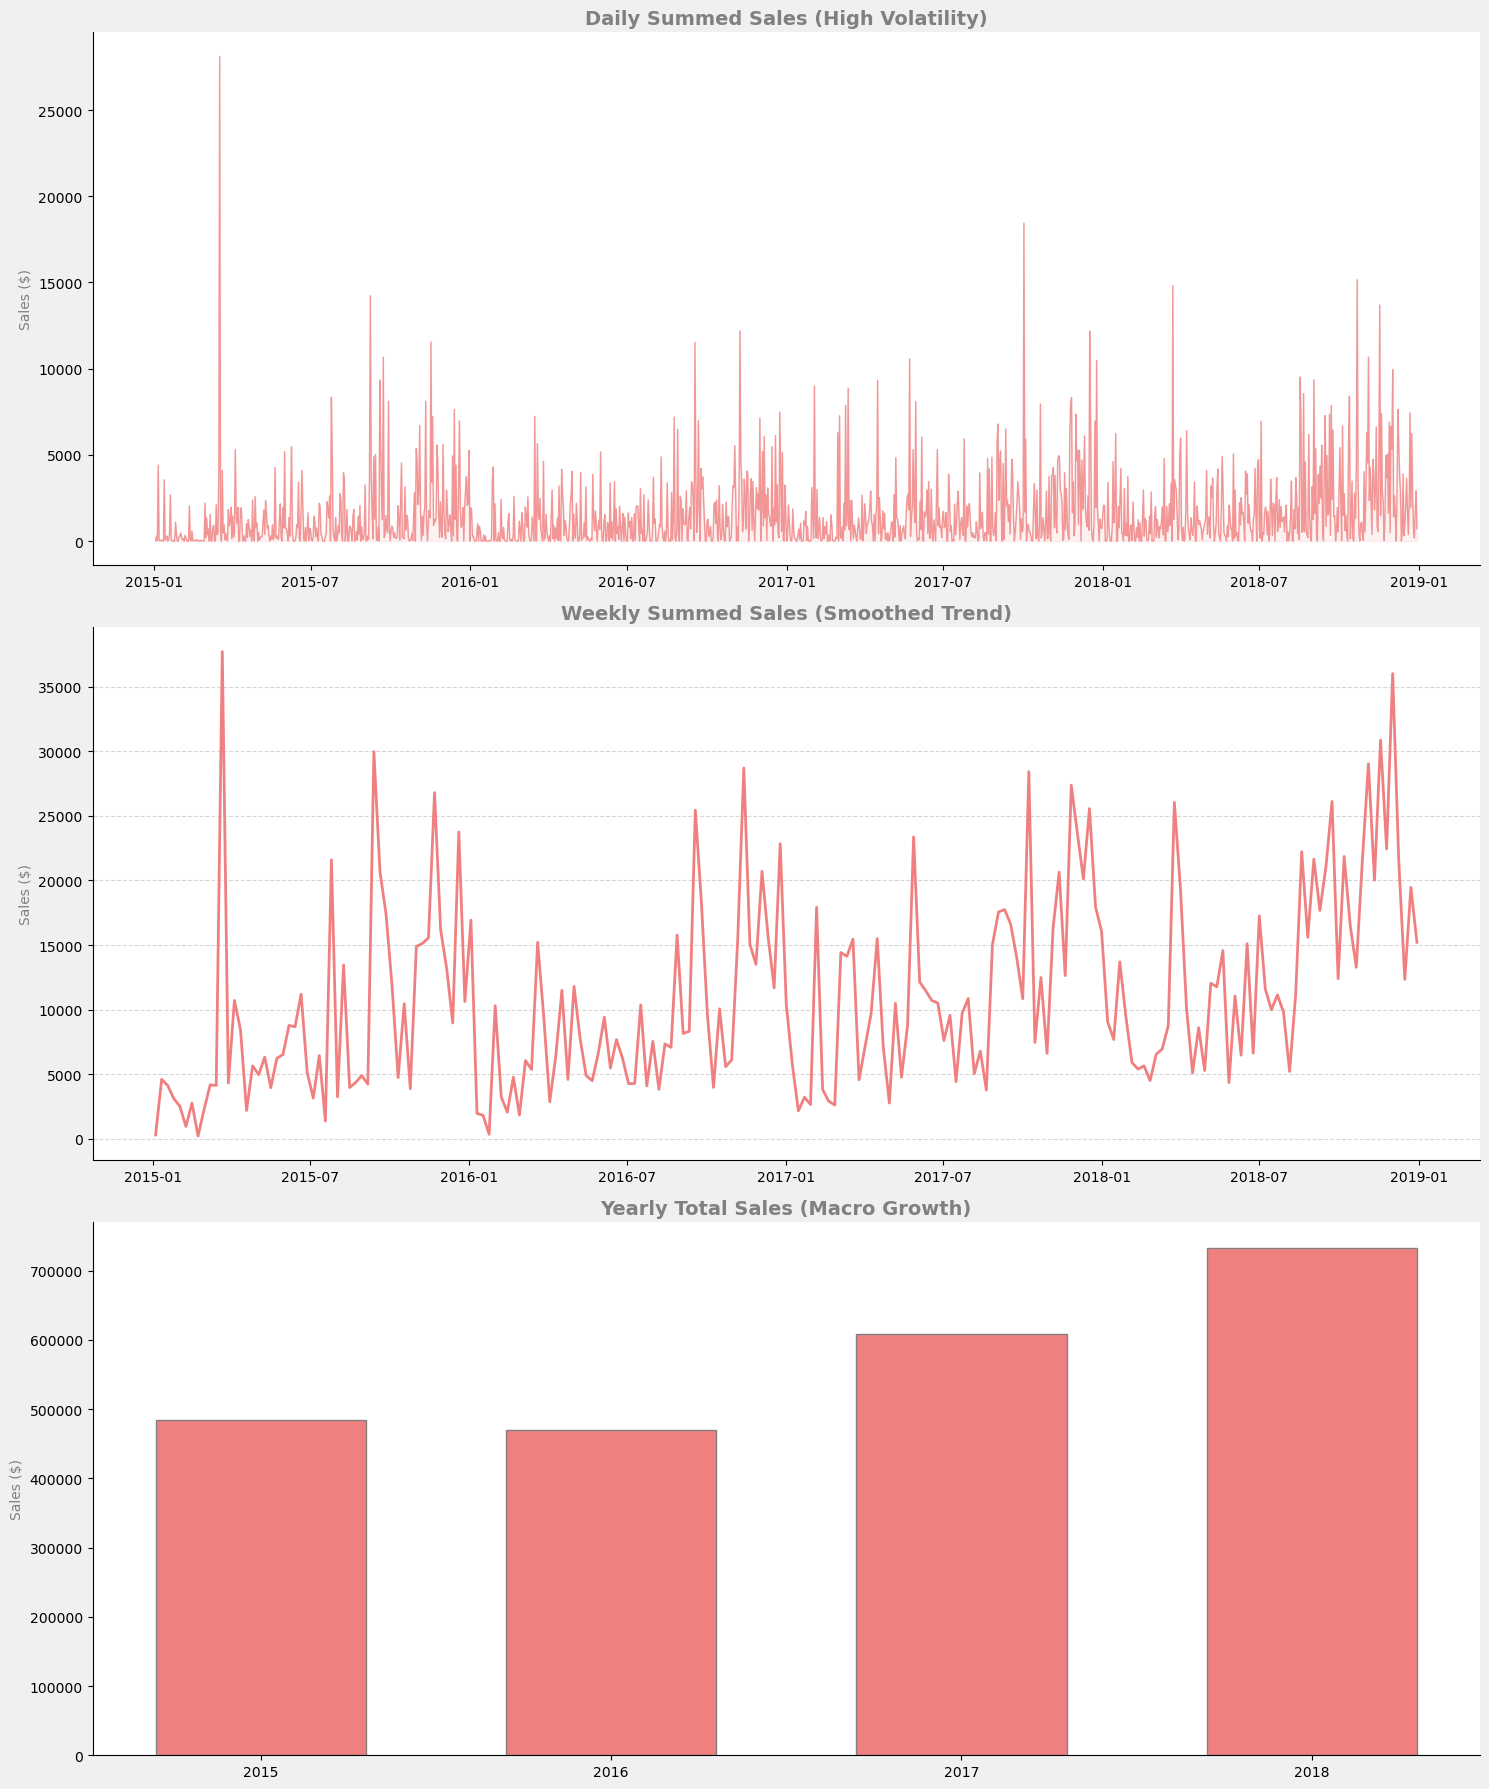

In [77]:
import matplotlib.pyplot as plt

# Ensure 'Order Date' is datetime and set as index for resampling
df_long['Order Date'] = pd.to_datetime(df_long['Order Date'])
temp_df = df_long.set_index('Order Date')

# Resampling data
# We group by the index and sum the sales for each period
daily_res = temp_df['Sales'].resample('D').sum()
weekly_res = temp_df['Sales'].resample('W').sum()
yearly_res = temp_df['Sales'].resample('Y').sum()

# Plotting Configuration
fig, axes = plt.subplots(3, 1, figsize=(15, 18), facecolor='#f0f0f0')
colors = {'red': '#f08080', 'gray': '#808080'} # Light milky red and gray

# --- Subplot 1: Daily Sales ---
axes[0].plot(daily_res.index, daily_res.values, color=colors['red'], linewidth=1, alpha=0.8)
axes[0].set_title('Daily Summed Sales (High Volatility)', fontsize=14, fontweight='bold', color=colors['gray'])
axes[0].fill_between(daily_res.index, daily_res.values, color=colors['red'], alpha=0.1)

# --- Subplot 2: Weekly Sales ---
axes[1].plot(weekly_res.index, weekly_res.values, color=colors['red'], linewidth=2)
axes[1].set_title('Weekly Summed Sales (Smoothed Trend)', fontsize=14, fontweight='bold', color=colors['gray'])
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# --- Subplot 3: Yearly Sales ---
# Using a bar chart for yearly to emphasize annual totals
years = yearly_res.index.year.astype(str)
axes[2].bar(years, yearly_res.values, color=colors['red'], edgecolor=colors['gray'], width=0.6)
axes[2].set_title('Yearly Total Sales (Macro Growth)', fontsize=14, fontweight='bold', color=colors['gray'])

# Aesthetic adjustments
for ax in axes:
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Sales ($)', color=colors['gray'])

plt.tight_layout()
plt.show()

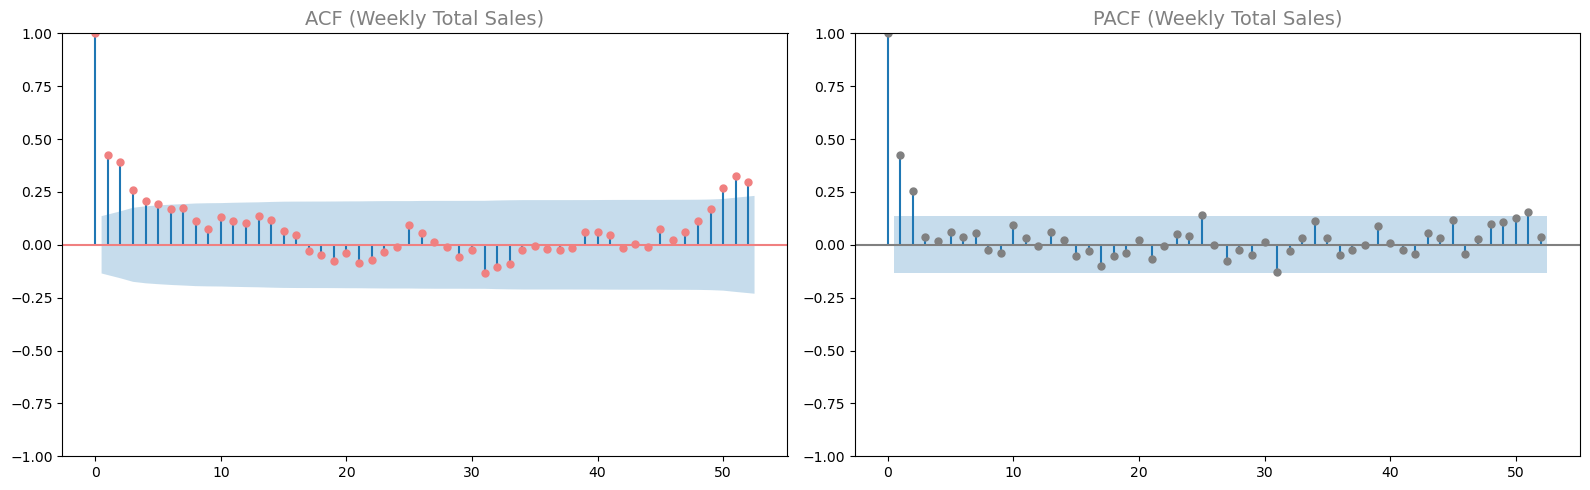

In [92]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Resample df_long to Weekly ('W') for each Subcategory
# Using 'Order Date' as index
df_weekly = df_long.set_index('Order Date').groupby('Subcategory')['Sales'].resample('W').sum().reset_index()

# 2. Pick a representative item or use the Total for the Global View
total_weekly = df_weekly.groupby('Order Date')['Sales'].sum()

# 3. Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(total_weekly, lags=52, ax=axes[0], color='#f08080') # Milky Red
axes[0].set_title('ACF (Weekly Total Sales)', fontsize=14, color='#808080')

plot_pacf(total_weekly, lags=52, ax=axes[1], color='#808080', method='ywm') # Gray
axes[1].set_title('PACF (Weekly Total Sales)', fontsize=14, color='#808080')

plt.tight_layout()
plt.show()

**based on pacf we'll use 1/2 lags per item, acf: we'll use 7 days moving average**

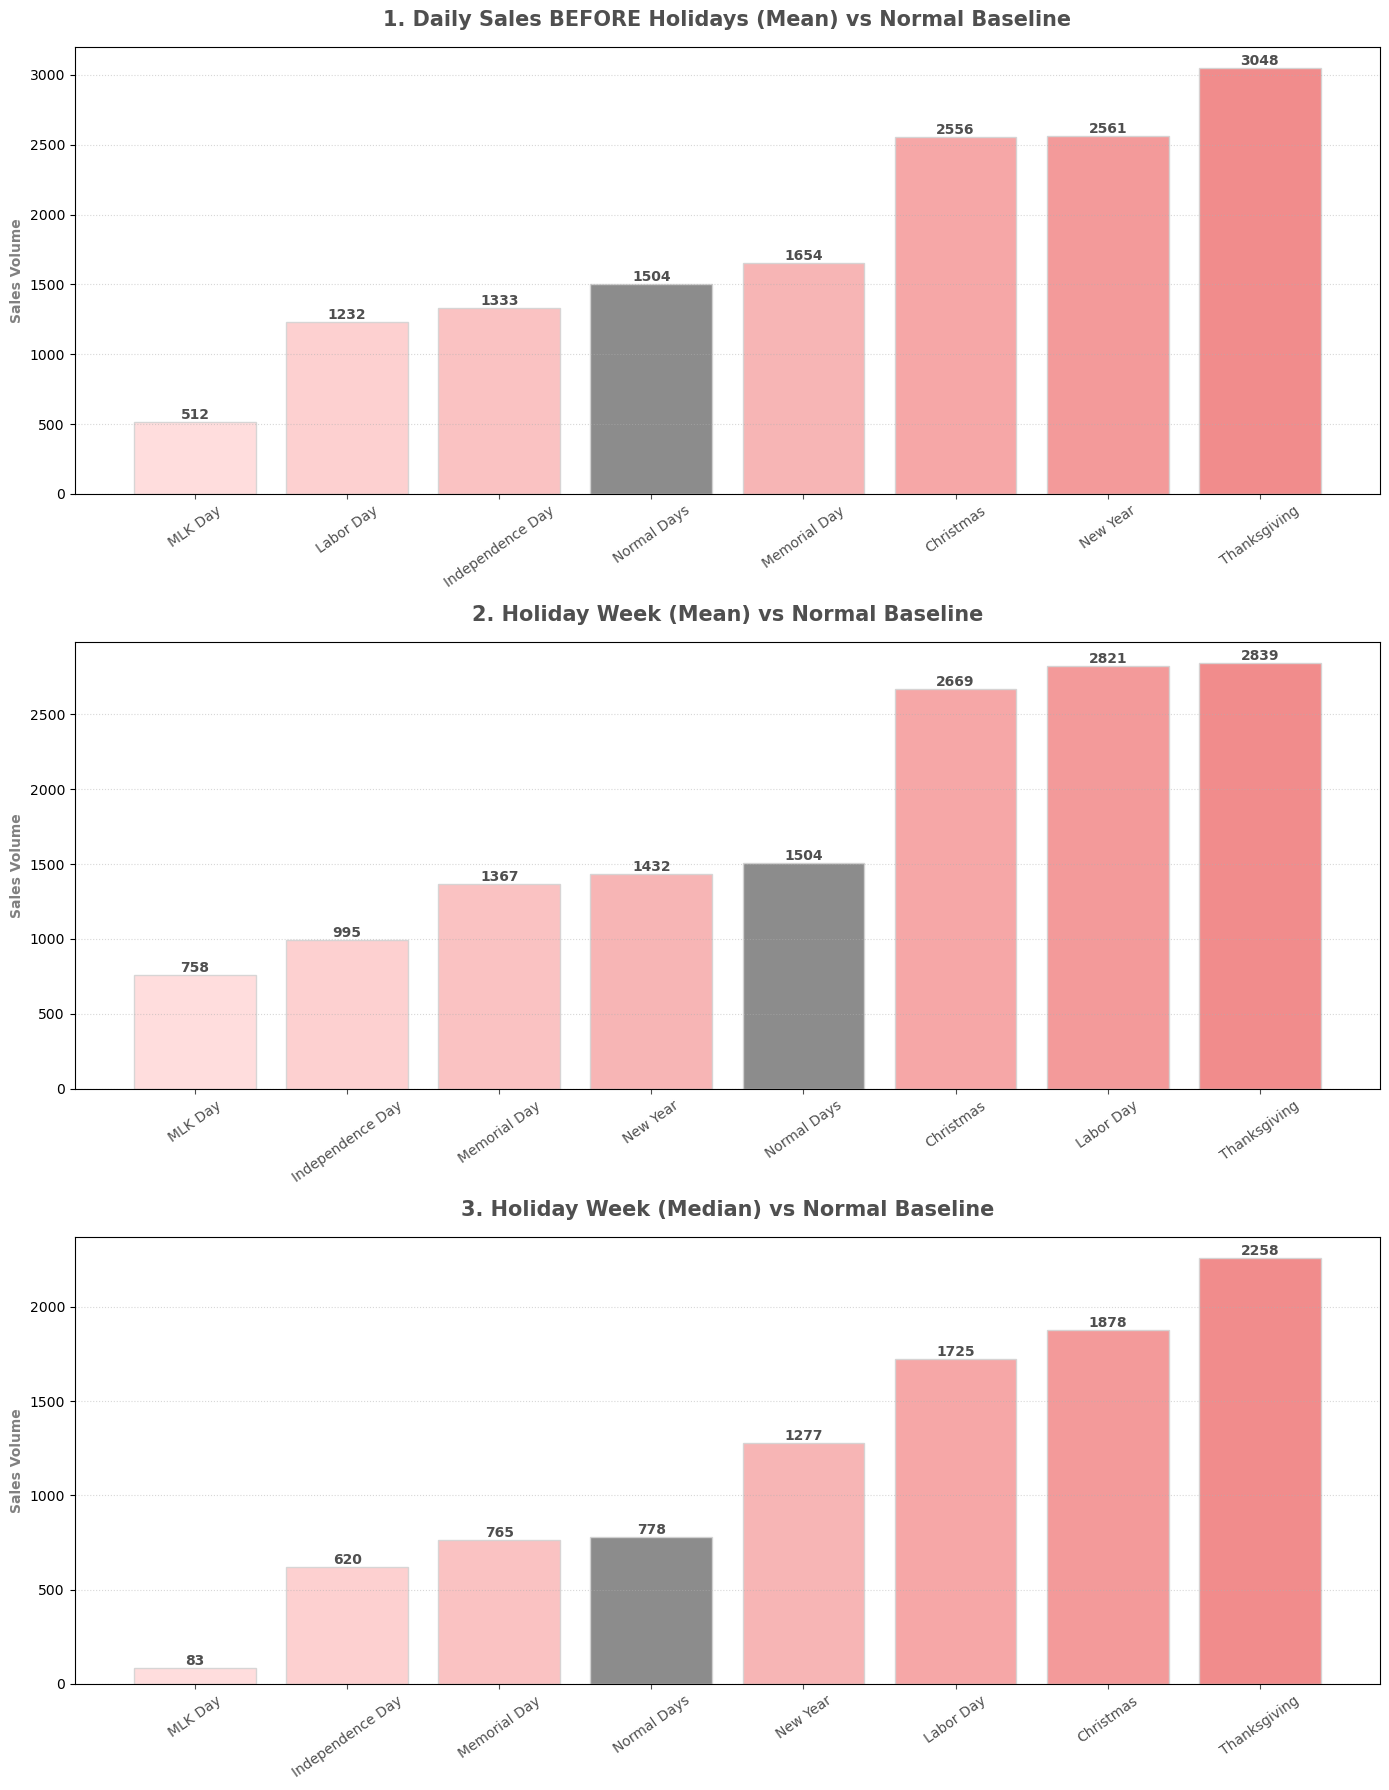

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# --- 1. PREP DATA ---
# Group df_long to get total daily sales (baseline for all items)
daily_sales = df_long.groupby('Order Date')['Sales'].sum()

# --- 2. DEFINE HOLIDAYS (2015-2018) ---
holidays_all = {
    'New Year': ['2015-01-01', '2016-01-01', '2017-01-01', '2018-01-01'],
    'MLK Day': ['2015-01-19', '2016-01-18', '2017-01-16', '2018-01-15'],
    'Memorial Day': ['2015-05-25', '2016-05-30', '2017-05-29', '2018-05-28'],
    'Independence Day': ['2015-07-04', '2016-07-04', '2017-07-04', '2018-07-04'],
    'Labor Day': ['2015-09-07', '2016-09-05', '2017-09-04', '2018-09-03'],
    'Thanksgiving': ['2015-11-26', '2016-11-24', '2017-11-23', '2018-11-22'],
    'Christmas': ['2015-12-25', '2016-12-25', '2017-12-25', '2018-12-25']
}

h_windows, p_windows, excluded = {}, {}, []

for name, dates in holidays_all.items():
    h_list, p_list = [], []
    for d in dates:
        center = pd.to_datetime(d)
        if center not in daily_sales.index: continue
        
        # Holiday: +/- 3 days | Pre-holiday: days -10 to -4
        h_s, h_e = center - pd.Timedelta(days=3), center + pd.Timedelta(days=3)
        p_s, p_e = center - pd.Timedelta(days=10), center - pd.Timedelta(days=4)
        
        h_data = daily_sales[h_s:h_e]
        p_data = daily_sales[p_s:p_e]
        
        if not h_data.empty: h_list.extend(h_data.values)
        if not p_data.empty: p_list.extend(p_data.values)
        excluded.extend(pd.date_range(p_s, h_e))

    if h_list: h_windows[name] = np.mean(h_list)
    if p_list: p_windows[name] = np.mean(p_list)

# --- 3. BASELINE ---
normal_days = daily_sales.drop(pd.to_datetime(list(set(excluded))), errors='ignore')

# --- 4. FORMATTING TOOLS ---
red_cmap = mcolors.LinearSegmentedColormap.from_list("milk_red", ["#FFDADA", "#F08080"])

def get_bar_colors(series):
    n_hols = len(series) - 1
    gradient = [red_cmap(i/max(1, n_hols-1)) for i in range(n_hols)]
    cols, g_idx = [], 0
    for label in series.index:
        if label == 'Normal Days':
            cols.append('#808080')
        else:
            cols.append(gradient[g_idx])
            g_idx += 1
    return cols

def draw_formatted_bars(ax, data, title):
    bar_cols = get_bar_colors(data)
    bars = ax.bar(data.index, data.values, color=bar_cols, edgecolor='#D3D3D3', alpha=0.9)
    ax.set_title(title, fontsize=15, color='#4F4F4F', fontweight='bold', pad=15)
    ax.set_ylabel('Sales Volume', color='#808080', fontweight='bold')
    ax.tick_params(axis='x', rotation=35, colors='#4F4F4F')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h, f'{int(h)}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#4F4F4F')

# --- 5. SERIES FOR PLOTTING ---
s1 = pd.Series({**p_windows, 'Normal Days': normal_days.mean()}).dropna().sort_values()
s2 = pd.Series({**h_windows, 'Normal Days': normal_days.mean()}).dropna().sort_values()
# For Median: recalculate from raw lists to be precise
h_medians = {name: np.median([v for d in dates for v in daily_sales[pd.to_datetime(d)-pd.Timedelta(days=3):pd.to_datetime(d)+pd.Timedelta(days=3)] if not daily_sales[pd.to_datetime(d)-pd.Timedelta(days=3):pd.to_datetime(d)+pd.Timedelta(days=3)].empty]) for name, dates in holidays_all.items()}
s3 = pd.Series({**h_medians, 'Normal Days': normal_days.median()}).dropna().sort_values()

# --- 6. PLOTTING ---
fig, axes = plt.subplots(3, 1, figsize=(14, 18), facecolor='white')

draw_formatted_bars(axes[0], s1, '1. Daily Sales BEFORE Holidays (Mean) vs Normal Baseline')
draw_formatted_bars(axes[1], s2, '2. Holiday Week (Mean) vs Normal Baseline')
draw_formatted_bars(axes[2], s3, '3. Holiday Week (Median) vs Normal Baseline')

plt.tight_layout()
plt.show()

**holidays show clear increase in sales versus regular days, we'll engineer them in features**

****

### Feature engineering